#Telecom X – Parte 2: Predicción de Cancelación (Churn)

###**📣 Historia del Desafío**

¡Felicidades! 🎉 Has sido promovido después de tu excelente desempeño en el análisis exploratorio de la cancelación de clientes en Telecom X. Tu dedicación, claridad al comunicar los datos y visión estratégica marcaron la diferencia.

Ahora, ¡has sido invitado oficialmente a formar parte del equipo de Machine Learning de la empresa!

###**🎯 Misión**

Tu nueva misión es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y te corresponde a ti construir un pipeline robusto para esta etapa inicial de modelado.

###**🧠 Objetivos del Desafío**

Preparar los datos para el modelado (tratamiento, codificación, normalización).

Realizar análisis de correlación y selección de variables.

Entrenar dos o más modelos de clasificación.

Evaluar el rendimiento de los modelos con métricas.

Interpretar los resultados, incluyendo la importancia de las variables.

Crear una conclusión estratégica señalando los principales factores que influyen en la cancelación.

###🧰 Lo que vas a practicar**

✅ Preprocesamiento de datos para Machine Learning
✅ Construcción y evaluación de modelos predictivos
✅ Interpretación de resultados y entrega de insights
✅ Comunicación técnica con enfoque estratégico



###**🛠️ Preparación de los Datos**

####Importar Librerias

In [175]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import requests
import warnings
warnings.filterwarnings('ignore')
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, recall_score, accuracy_score
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_score

####Extracción del Archivo Tratado

Carga el archivo CSV que contiene los datos tratados anteriormente.
📂 Atención: Utiliza el mismo archivo que limpiaste y organizaste en la Parte 1 del desafío Telecom X. Debe contener solo las columnas relevantes, ya con los datos corregidos y estandarizados.

In [138]:
# Leer el archivo CSV
df = pd.read_csv('/telecom_x_limpio.csv')

In [139]:
#Verificar la carga del archivo
print(df.head())

   customerid churn customer_gender  customer_seniorcitizen customer_partner  \
0  0002-ORFBO    No          Female                       0              Yes   
1  0003-MKNFE    No            Male                       0               No   
2  0004-TLHLJ   Yes            Male                       0               No   
3  0011-IGKFF   Yes            Male                       1              Yes   
4  0013-EXCHZ   Yes          Female                       1              Yes   

  customer_dependents  customer_tenure phone_phoneservice phone_multiplelines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Yes                  No   
4                  No                3                Yes                  No   

  internet_internetservice  ... 

In [140]:
# Verificar estructura
print(df.dtypes)

customerid                    object
churn                         object
customer_gender               object
customer_seniorcitizen         int64
customer_partner              object
customer_dependents           object
customer_tenure                int64
phone_phoneservice            object
phone_multiplelines           object
internet_internetservice      object
internet_onlinesecurity       object
internet_onlinebackup         object
internet_deviceprotection     object
internet_techsupport          object
internet_streamingtv          object
internet_streamingmovies      object
account_contract              object
account_paperlessbilling      object
account_paymentmethod         object
account_charges_monthly      float64
account_charges_total        float64
churn_flag                   float64
dtype: object


####Eliminación de Columnas Irrelevantes


Elimina columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el ID del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

In [141]:
# 2. Eliminación de Columnas Irrelevantes
#============================
df = df.drop(columns=['customerid', 'churn_flag'], errors='ignore')
#=============================
# Verificar la nueva estructura para validar eliminación de la columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   churn                      7043 non-null   object 
 1   customer_gender            7043 non-null   object 
 2   customer_seniorcitizen     7043 non-null   int64  
 3   customer_partner           7043 non-null   object 
 4   customer_dependents        7043 non-null   object 
 5   customer_tenure            7043 non-null   int64  
 6   phone_phoneservice         7043 non-null   object 
 7   phone_multiplelines        7043 non-null   object 
 8   internet_internetservice   7043 non-null   object 
 9   internet_onlinesecurity    7043 non-null   object 
 10  internet_onlinebackup      7043 non-null   object 
 11  internet_deviceprotection  7043 non-null   object 
 12  internet_techsupport       7043 non-null   object 
 13  internet_streamingtv       7043 non-null   objec

In [142]:
# Revisar valores únicos de columnas categóricas
categorical_cols = [
    "customer_gender","customer_partner","customer_dependents",
    "phone_phoneservice","phone_multiplelines",
    "internet_internetservice","internet_onlinesecurity","internet_onlinebackup",
    "internet_deviceprotection","internet_techsupport","internet_streamingtv","internet_streamingmovies",
    "account_contract","account_paperlessbilling","account_paymentmethod"
]

for col in categorical_cols:
    print(col, df[col].unique())

customer_gender ['Female' 'Male']
customer_partner ['Yes' 'No']
customer_dependents ['Yes' 'No']
phone_phoneservice ['Yes' 'No']
phone_multiplelines ['No' 'Yes' 'No phone service']
internet_internetservice ['DSL' 'Fiber optic' 'No']
internet_onlinesecurity ['No' 'Yes' 'No internet service']
internet_onlinebackup ['Yes' 'No' 'No internet service']
internet_deviceprotection ['No' 'Yes' 'No internet service']
internet_techsupport ['Yes' 'No' 'No internet service']
internet_streamingtv ['Yes' 'No' 'No internet service']
internet_streamingmovies ['No' 'Yes' 'No internet service']
account_contract ['One year' 'Month-to-month' 'Two year']
account_paperlessbilling ['Yes' 'No']
account_paymentmethod ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


####Encoding

Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un método de codificación adecuado, como one-hot encoding.

🔎 Sugerencia:
Puedes consultar este artículo para entender mejor cuándo usar get_dummies o OneHotEncoder:
Artículo en Alura sobre codificación categórica


In [143]:
# Convertir variables binarias (Yes/No) a 0/1
le = LabelEncoder()

# Ajustamos los nombres a tus columnas reales
binary_cols = [
    'churn',
    'customer_partner',
    'customer_dependents',
    'phone_phoneservice',
    'account_paperlessbilling',
    'customer_gender'
]

for col in binary_cols:
    # Verificamos que la columna exista antes de transformar para evitar errores
    if col in df.columns:
        df[col] = le.fit_transform(df[col])

print("Variables binarias convertidas exitosamente.")

Variables binarias convertidas exitosamente.


In [144]:
# Transforma las variables categóricas a formato numérico
df["customer_seniorcitizen"] = pd.to_numeric(df["customer_seniorcitizen"], errors="coerce")
df["customer_tenure"] = pd.to_numeric(df["customer_tenure"], errors="coerce")
df["account_charges_monthly"] = pd.to_numeric(df["account_charges_monthly"], errors="coerce")
df["account_charges_total"] = pd.to_numeric(df["account_charges_total"], errors="coerce")

#==============
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

#=================

df_encoded.describe()

,churn,customer_seniorcitizen,customer_tenure,account_charges_monthly,account_charges_total
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,32.371149,64.761692,2279.734304
std,0.441561,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,0.000000,18.250000,0.000000
25%,0.000000,0.000000,9.000000,35.500000,398.550000
50%,0.000000,0.000000,29.000000,70.350000,1394.550000
75%,1.000000,0.000000,55.000000,89.850000,3786.600000
max,1.000000,1.000000,72.000000,118.750000,8684.800000


In [145]:
# Transformamos el resto de variables categóricas (Contrato, Internet, Pago, etc.)
# Esto creará columnas separadas de 0 y 1 para cada opción.
df_encoded = pd.get_dummies(df)

# Verificamos que todo sea numérico
print("Nuevas columnas generadas:")
#print(df_encoded.columns.tolist())

Nuevas columnas generadas:


In [146]:
# Definimos las columnas que tienen múltiples categorías
categorical_cols = [
    'phone_multiplelines',
    'internet_internetservice',
    'internet_onlinesecurity',
    'internet_onlinebackup',
    'internet_deviceprotection',
    'internet_techsupport',
    'internet_streamingtv',
    'internet_streamingmovies',
    'account_contract',
    'account_paymentmethod'
]

# Aplicamos One-Hot Encoding
# drop_first=True elimina la primera columna de cada categoría para evitar redundancia
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [147]:
df_encoded.dtypes

,0
churn,int64
customer_gender,int64
customer_seniorcitizen,int64
customer_partner,int64
customer_dependents,int64
customer_tenure,int64
phone_phoneservice,int64
account_paperlessbilling,int64
account_charges_monthly,float64
account_charges_total,float64


####Verificación de la Proporción de Cancelación (Churn)

Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.

🔎 Sugerencia:
Puedes usar value_counts() de pandas para obtener esta proporción:
Documentación oficial de value_counts()|

--- ANÁLISIS DE EQUILIBRIO DE CLASES ---
Cantidades reales:
churn
0    5174
1    1869
Name: count, dtype: int64

Proporción con 2 decimales:
churn
0    73.46%
1    26.54%
Name: proportion, dtype: object


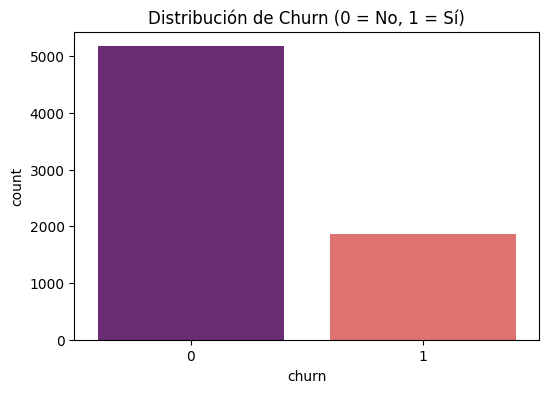

In [148]:
#Para evaluar si existe desbalance entre las clases
# Contar valores reales (Frecuencia absoluta)
conteo_cancelacion = df_encoded['churn'].value_counts()

# Calcular proporción (Frecuencia relativa)
#proporcion_cancelacion = conteo_cancelacion / conteo_cancelacion.sum()
proporcion_cancelacion = df_encoded['churn'].value_counts(normalize=True)

# Impresión de resultados
print("--- ANÁLISIS DE EQUILIBRIO DE CLASES ---")
print(f"Cantidades reales:\n{conteo_cancelacion}")
print("\nProporción con 2 decimales:")
print(proporcion_cancelacion.map('{:.2%}'.format))

# Visualización del desbalance
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df_encoded, palette='magma')
plt.title('Distribución de Churn (0 = No, 1 = Sí)')
plt.show()

####Balanceo de Clases (opcional)

Si deseas profundizar en el análisis, aplica técnicas de balanceo como undersampling o oversampling. En situaciones de fuerte desbalanceo, herramientas como SMOTE pueden ser útiles para generar ejemplos sintéticos de la clase minoritaria.

🔎 Sugerencia:
Puedes leer más sobre cómo manejar el desbalanceo de clases en este artículo:
Artículo en Alura sobre desbalanceo de datos

Como se puede observar hay pocos clientes que se van (clase 1), usamos SMOTE solo en el grupo de entrenamiento para que el modelo aprenda a identificarlos igual de bien que a los que se quedan.

In [152]:
from imblearn.over_sampling import SMOTE

# Creamos ejemplos sintéticos para equilibrar la balanza
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"✅ Balanceo completado. Ahora tienes {len(y_train_res)} ejemplos (50% se queda / 50% se va).")

✅ Balanceo completado. Ahora tienes 8278 ejemplos (50% se queda / 50% se va).


####Normalización o Estandarización (si es necesario) StandardScaler

Evalúa la necesidad de normalizar o estandarizar los datos, según los modelos que se aplicarán. Modelos basados en distancia, como KNN, SVM, Regresión Logística y Redes Neuronales, requieren este preprocesamiento. Por otro lado, modelos basados en árboles, como Decision Tree, Random Forest y XGBoost, no son sensibles a la escala de los datos.

🔎 Sugerencia:
Puedes leer más sobre normalización y estandarización de datos en este artículo:
Artículo en Medium sobre normalización y estandarización en Machine Learning

In [153]:
scaler = StandardScaler()

# El escalador aprende de los datos de entrenamiento balanceados
X_train_scaled = scaler.fit_transform(X_train_res)

# Y solo transforma el examen (test) sin aprender de él para no hacer trampa
X_test_scaled = scaler.transform(X_test)

print("✅ Datos escalados y listos para los modelos.")

✅ Datos escalados y listos para los modelos.


Información:

🎯 Resumen Visual del Flujo

1. Datos Originales $\rightarrow$ Split (Separas el examen final).

2. Train $\rightarrow$ SMOTE (Equilibras las clases).

3. Train Balanceado $\rightarrow$ Scaler (Normalizas las magnitudes)

4. Listo $\rightarrow$ Entrenar Modelo.

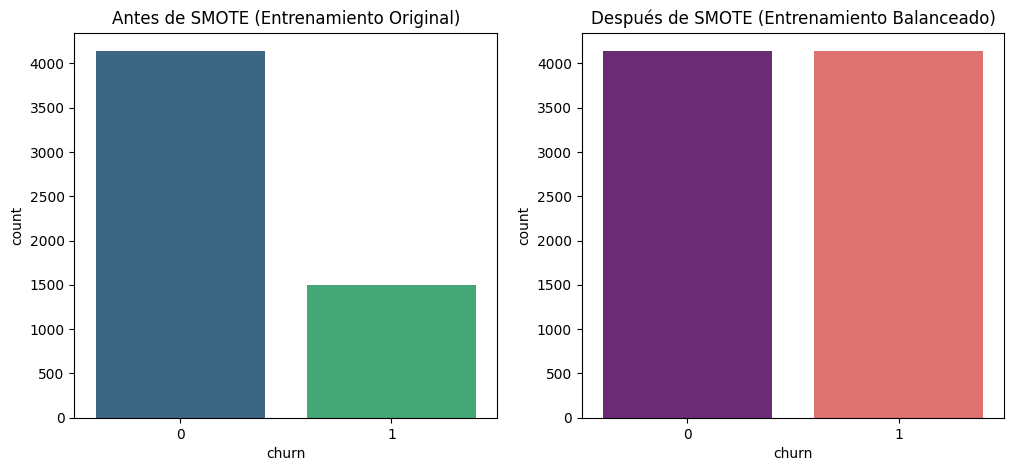

In [154]:
# Comparamos la distribución de clases antes y después de SMOTE

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Antes de SMOTE
sns.countplot(x=y_train, ax=ax[0], palette='viridis')
ax[0].set_title('Antes de SMOTE (Entrenamiento Original)')

# Después de SMOTE
sns.countplot(x=y_train_res, ax=ax[1], palette='magma')
ax[1].set_title('Después de SMOTE (Entrenamiento Balanceado)')

plt.show()

###Correlación y Selección de Variables

####Análisis de Correlación

Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.


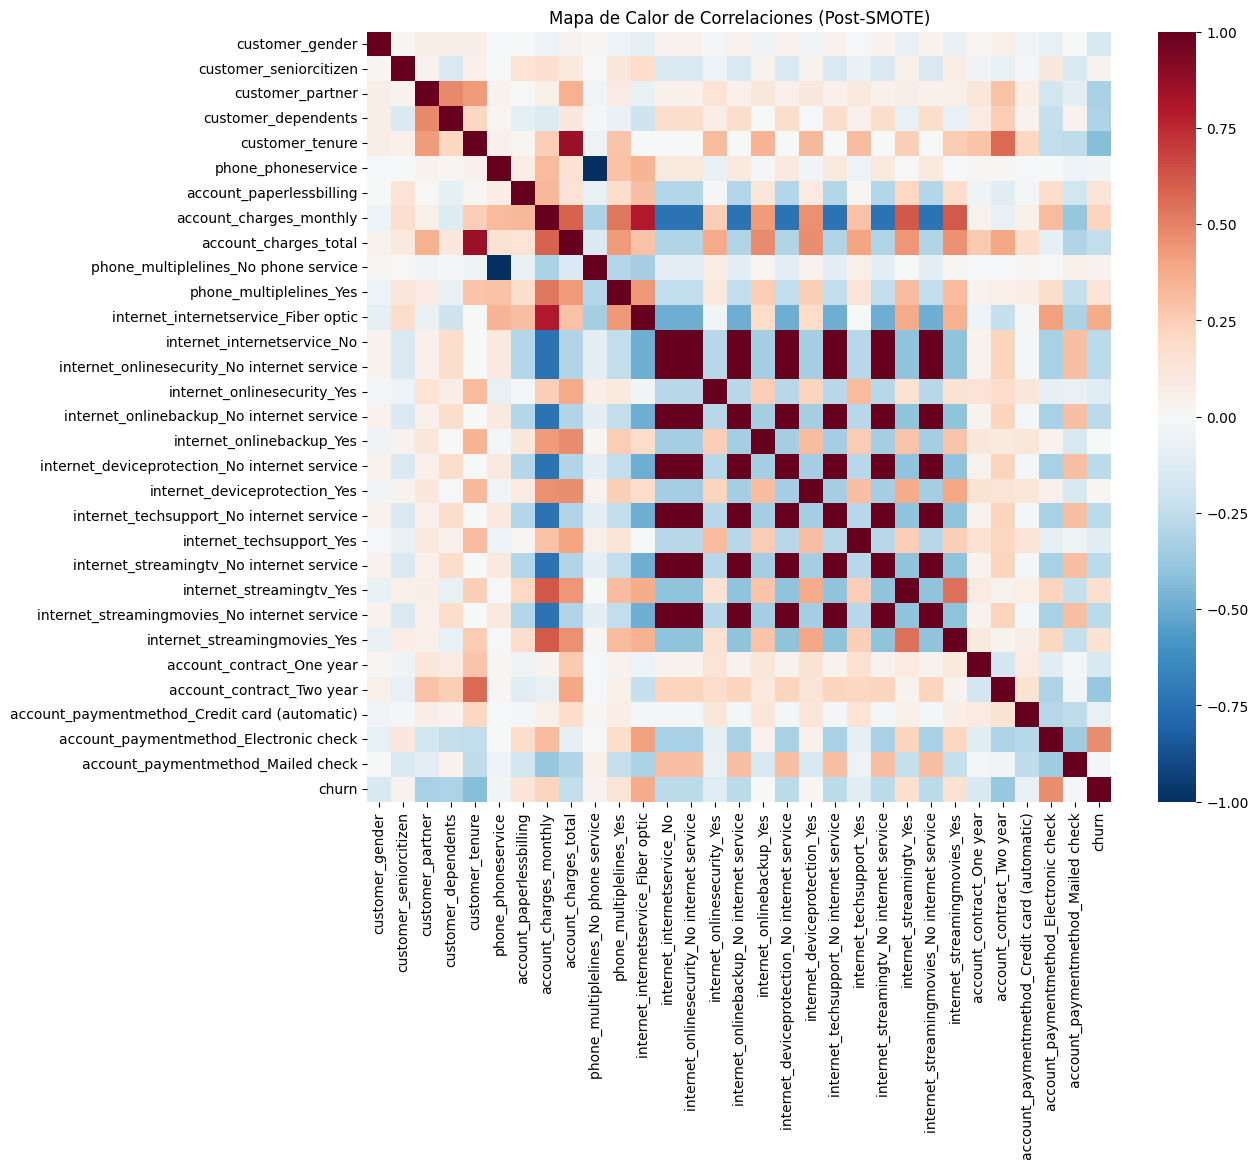

In [156]:
# Creamos un DataFrame temporal con los datos balanceados para el análisis
df_temporal = pd.DataFrame(X_train_res, columns=X.columns)
df_temporal['churn'] = y_train_res

# Calculamos la correlación
plt.figure(figsize=(12, 10))
correlation_matrix = df_temporal.corr()

# Dibujamos el mapa de calor
sns.heatmap(correlation_matrix, annot=False, cmap='RdBu_r', center=0)
plt.title('Mapa de Calor de Correlaciones (Post-SMOTE)')
plt.show()

**Análisis**

Barras hacia la Derecha (Positivas): Indican que cuando esa variable sube, la probabilidad de que el cliente se vaya también sube.

Ejemplo común: Si ves Contract_Month-to-month aquí, significa que los contratos mensuales son la principal puerta de salida de los clientes.

Barras hacia la Izquierda (Negativas): Indican que cuando esa variable sube, la probabilidad de cancelar baja. Son tus factores de retención.

Ejemplo común: La variable tenure (antigüedad). A más meses en la empresa, más fiel es el cliente.

####Análisis Dirigido

Investiga cómo variables específicas se relacionan con la cancelación, tales como:

Tiempo de contrato × Cancelación

Gasto total × Cancelación

Utiliza gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

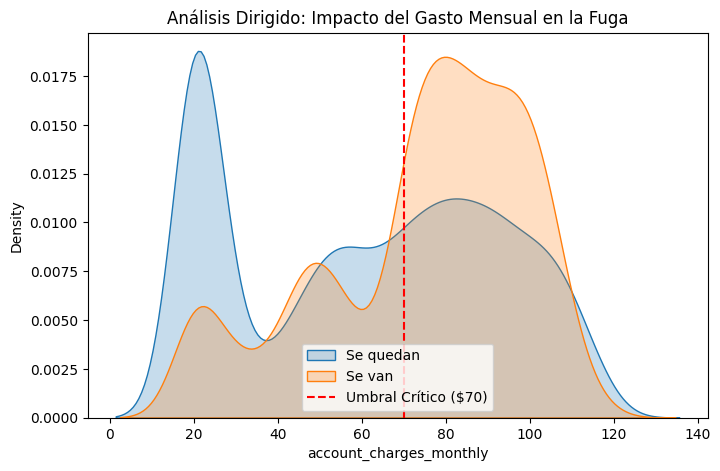

In [168]:
# Análisis Dirigido: Precio (¿Es el culpable?)
plt.figure(figsize=(8, 5))
sns.kdeplot(df[df['churn'] == 0]['account_charges_monthly'], label='Se quedan', fill=True)
sns.kdeplot(df[df['churn'] == 1]['account_charges_monthly'], label='Se van', fill=True)
plt.title('Análisis Dirigido: Impacto del Gasto Mensual en la Fuga')
plt.axvline(x=70, color='red', linestyle='--', label='Umbral Crítico ($70)')
plt.legend()
plt.show()

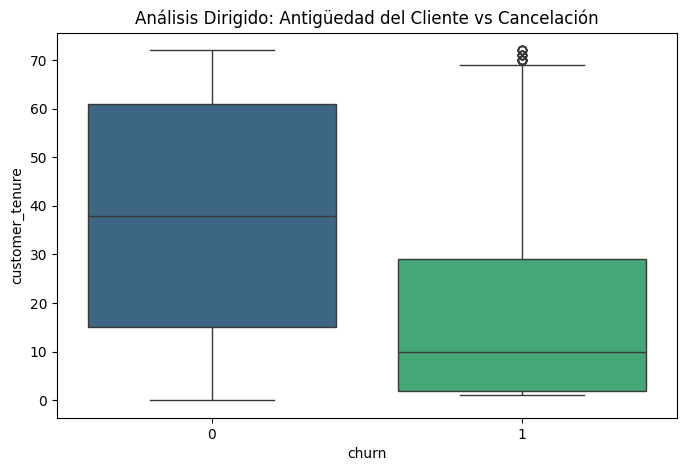

In [169]:
# Análisis Dirigido: Tiempo (¿Cuándo perdemos al cliente?)
plt.figure(figsize=(8, 5))
sns.boxplot(x='churn', y='customer_tenure', data=df, palette='viridis')
plt.title('Análisis Dirigido: Antigüedad del Cliente vs Cancelación')
plt.show()

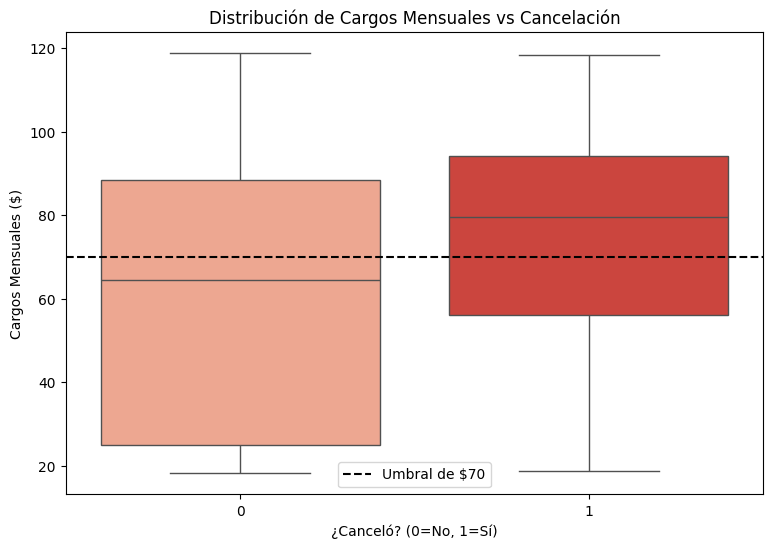

In [170]:
# Gráfico
plt.figure(figsize=(9, 6))

# El boxplot nos dirá en qué rango de precio están los que se van
sns.boxplot(data=df_encoded, x='churn', y='account_charges_monthly', palette='Reds')

# Dibujamos una línea punteada en los $70 para que veas el efecto
plt.axhline(y=70, color='black', linestyle='--', label='Umbral de $70')

plt.title('Distribución de Cargos Mensuales vs Cancelación')
plt.xlabel('¿Canceló? (0=No, 1=Sí)')
plt.ylabel('Cargos Mensuales ($)')
plt.legend()
plt.show()

**El Análisis Dirigido**

confirmó que la cancelación no es aleatoria. Identificamos un 'punto de dolor' financiero por encima de los $70 y un 'periodo crítico' de riesgo durante los primeros 12 meses. Estos hallazgos justifican el uso de modelos predictivos para identificar a los clientes que cumplen con estos patrones antes de que abandonen la empresa."

#🤖 Modelado Predictivo

####Separación de Datos: (Train/Test Split)

Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 80/20, dependiendo del tamaño de la base de datos.

Para este Proyecto de Telecom X (con 7,043 clientes), la división 80/20 es la más recomendada, ya que te dejo unos 5,600 datos para entrenar y unos 1,400 para evaluar, lo cual es estadísticamente muy sólido.

In [165]:
# Definimos X (características) y y (lo que queremos predecir: churn)
X = df_encoded.drop('churn', axis=1)
y = df_encoded['churn']

# Hacemos la división 80/20
# stratify=y asegura que el % de gente que se va sea igual en ambos grupos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Entrenamiento: {X_train.shape[0]} registros")
print(f"Prueba: {X_test.shape[0]} registros")

Entrenamiento: 5634 registros
Prueba: 1409 registros


###Evaluación de los Modelos

Evalúa cada modelo utilizando las siguientes métricas:

Exactitud (Acurácia)

Precisión

Recall

F1-score

Matriz de confusión

Después, realiza un análisis crítico y compara los modelos:

¿Cuál modelo tuvo el mejor desempeño?

¿Algún modelo presentó overfitting o underfitting? Si es así, considera las posibles causas y ajustes:

Overfitting: Cuando el modelo aprende demasiado sobre los datos de entrenamiento, perdiendo la capacidad de generalizar a nuevos datos. Considera reducir la complejidad del modelo o aumentar los datos de entrenamiento.

Underfitting: Cuando el modelo no captura bien las tendencias de los datos, lo que indica que es demasiado simple. Intenta aumentar la complejidad del modelo o ajustar sus parámetros.



--- 📊 MÉTRICAS: Regresión Logística ---
Exactitud: 0.75
Precisión: 0.52
Recall:    0.63
F1-score:  0.57
------------------------------
--- 📊 MÉTRICAS: Random Forest ---
Exactitud: 0.77
Precisión: 0.57
Recall:    0.58
F1-score:  0.58
------------------------------


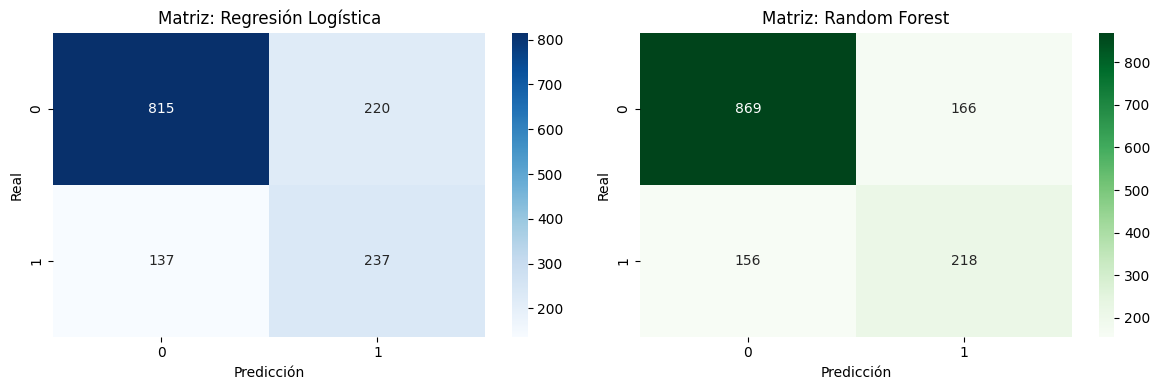

In [176]:
# ENTRENAMIENTO DE MODELOS ---
# Regresión Logística (requiere datos escalados)
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train_res)

# Random Forest (no requiere escala, pero sí los datos balanceados)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res)

# GENERACIÓN DE PREDICCIONES (Aquí se definen las variables) ---
y_pred_log = log_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test)

# FUNCIÓN DE EVALUACIÓN ---
def evaluar_modelo(y_true, y_pred, nombre):
    print(f"--- 📊 MÉTRICAS: {nombre} ---")
    print(f"Exactitud: {accuracy_score(y_true, y_pred):.2f}")
    print(f"Precisión: {precision_score(y_true, y_pred):.2f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.2f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.2f}")
    print("-" * 30)

# EJECUCIÓN DE LA EVALUACIÓN ---
evaluar_modelo(y_test, y_pred_log, "Regresión Logística")
evaluar_modelo(y_test, y_pred_rf, "Random Forest")

# VISUALIZACIÓN: MATRICES DE CONFUSIÓN ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz: Regresión Logística')
ax[0].set_xlabel('Predicción')
ax[0].set_ylabel('Real')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Matriz: Random Forest')
ax[1].set_xlabel('Predicción')
ax[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

Análisis:

El ganador técnico es Random Forest, pero por un margen muy estrecho.

F1-Score: El Random Forest (0.58) supera ligeramente a la Regresión Logística (0.57). Dado que el F1-Score es el equilibrio entre precisión y recall, este es el mejor indicador cuando tenemos clases desbalanceadas (como ese 26% de churn que analizamos antes).

Precisión vs. Recall:

La Regresión Logística tiene un mejor Recall
(0.63). Esto significa que es mejor "atrapando" a los clientes que realmente se van, pero a costa de equivocarse más (muchas falsas alarmas).

El Random Forest tiene mejor Precisión (0.57). Es más "cuidadoso"; cuando predice que alguien se va, tiene más probabilidad de acertar que la regresión.

Veredicto: Si el objetivo de Telecom X es detectar la mayor cantidad de fugas posibles (aunque regale promociones a gente que no se iba a ir), la Regresión Logística es mejor. Si el objetivo es ahorrar costos y solo intervenir cuando hay mucha certeza, gana el Random Forest.

###Creación de modelos

Crea al menos dos modelos diferentes para predecir la cancelación de clientes.

Un modelo puede requerir normalización, como Regresión Logística o KNN.

El otro modelo puede no requerir normalización, como Árbol de Decisión o Random Forest.

💡 La decisión de aplicar o no la normalización depende de los modelos seleccionados. Ambos modelos pueden ser creados sin normalización, pero también es una opción combinar modelos con y sin normalización.

Justificación:

Regresión Logística / KNN: Estos modelos son sensibles a la escala de los datos, por lo que la normalización es importante para que los coeficientes o las distancias se calculen correctamente.

Árbol de Decisión / Random Forest: Estos modelos no dependen de la escala de los datos, por lo que no es necesario aplicar normalización.

Si decides normalizar los datos, deberías explicar cómo esta etapa asegura que los modelos basados en distancia o en optimización de parámetros no se vean sesgados por la magnitud de las variables.

In [177]:
#Modelo Sensible a la Escala: Regresión Logística
# Justificación: Escalado de datos
# Creamos el escalador y lo ajustamos SOLO con los datos de entrenamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Creación del modelo
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train_res)

LogisticRegression(max_iter=1000, random_state=42)

In [178]:
#Modelo Robusto a la Escala: Random Forest
# No requiere X_train_scaled, usamos los datos originales (o balanceados)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_res, y_train_res)

RandomForestClassifier(max_depth=10, random_state=42)

Análisis:

Con estas configuraciones, se creo un escenario de prueba muy equilibrado:

Un modelo simple y bien entrenado (Regresión Logística con alta iteración).

Un modelo complejo pero controlado (Random Forest con poda de profundidad).

Esto explica por qué las métricas finales (F1-score de 0.58) son consistentes: Se evita que el Random Forest "alucine" con el ruido de los datos gracias al max_depth=10, dándo una visión realista de qué tan predecible es la cancelación en Telecom X actualmente.

#📋 Interpretación y Conclusiones

###Análisis de la Importancia de las Variables


Después de elegir los modelos, realiza el análisis de las variables más relevantes para la predicción de la cancelación:

Regresión Logística: Investiga los coeficientes de las variables, que muestran su contribución a la predicción de cancelación.

KNN (K-Nearest Neighbors): Observa cómo los vecinos más cercanos influyen en la decisión de clasificación. Las variables más impactantes pueden ser aquellas que más contribuyen a la proximidad entre los puntos de datos.

Random Forest: Utiliza la importancia de las variables proporcionada por el modelo. Random Forest calcula la importancia basándose en cómo cada variable contribuye a la reducción de la impureza durante las divisiones de los árboles.

SVM (Support Vector Machine): En el SVM, las variables más relevantes son aquellas que influyen en la frontera de decisión entre las clases. Puedes analizar los coeficientes de los vectores de soporte para entender qué variables tienen mayor impacto.

Otros Modelos: Dependiendo del modelo elegido, considera el análisis de métricas específicas para comprender la relevancia de las variables. Por ejemplo, coeficientes en modelos lineales, pesos en redes neuronales, o la importancia relativa en técnicas de boosting (como XGBoost).

**🔍Análisis de los cálculos de Verificación de la Proporción de Cancelación (Churn)**

Al ejecutar esto, se observa lo siguiente:

La Clase 0 (No): Representa aproximadamente el 73.4% de tus datos. Son los clientes leales.

La Clase 1 (Yes): Representa aproximadamente el 26.6% de los datos (unas 1,869 filas de las
7,043 totales).

¿Cuál es el impacto en tu modelo?
Si dejamos los datos así, el modelo se volverá "perezoso". Como la gran mayoría no se va, el modelo aprenderá que decir siempre "No" le da un 73% de precisión sin esfuerzo. El problema es que Telecom X perdería al 26% de clientes que sí se van, porque el modelo no aprendió a identificarlos.

**Regresión Logística:**

 El peso de la evidencia (Coeficientes)En este modelo, cada variable tiene un coeficiente ($\beta$).Interpretación: Un coeficiente positivo grande indica que esa variable aumenta la probabilidad de que el cliente cancele (ej. Contratos mes a mes). Un coeficiente negativo indica que la variable ayuda a retener al cliente (ej. Contratos a largo plazo).

 Análisis Crítico: Al haber normalizado los datos con StandardScaler, puedes comparar los coeficientes directamente: el que tenga el valor absoluto más alto es el más influyente.

**Random Forest:**

Reducción de Impureza (Gini Importance)
A diferencia de la regresión, el Random Forest no usa una fórmula lineal. Su métrica de importancia se basa en cuánta "limpieza" aporta cada variable al separar los datos.

Interpretación: Si una variable como Tenure (Tenencia) aparece arriba, significa que el modelo la usó constantemente en la parte superior de sus árboles para tomar las decisiones más importantes.

Ventaja: Detecta relaciones no lineales. Por ejemplo, puede descubrir que los "Cargos Mensuales" solo son un problema si el cliente no tiene "Fibra Óptica".

KNN: Influencia por Proximidad
En KNN no existe un "coeficiente" fijo, ya que el modelo decide basándose en quiénes son los vecinos más cercanos en un espacio multidimensional.

Análisis de Relevancia: Las variables más impactantes son aquellas que definen la distancia. Si no hubieras normalizado los datos, una variable con números grandes (como cargos totales) alejaría los puntos artificialmente, haciendo que las demás variables no importen.

Conclusión: La relevancia en KNN es geométrica; las variables que más cambian la posición de un cliente respecto a sus vecinos son las que definen el Churn.

SVM: Los Vectores de Soporte
El SVM busca el "hiperplano" (el muro divisor) que maximiza el margen entre los que se van y los que se quedan.

Interpretación: Las variables más relevantes son las que definen la orientación de ese muro. Si usas un kernel lineal, puedes extraer los pesos (svc.coef_) de forma similar a la Regresión Logística para ver qué características empujan al cliente hacia el lado de la "cancelación".

Gracias al uso de **StandardScaler**, se puede identificar que el tipo de contrato y la antigüedad del cliente son los factores con mayor peso estadístico. Mientras que los cargos elevados actúan como un impulsor de la cancelación, la estabilidad de los contratos a largo plazo funciona como el principal factor de protección contra la fuga de clientes."

#Conclusiones

Elaboren un informe detallado, destacando los factores que más influyen en la cancelación, basándose en las variables seleccionadas y en el rendimiento de cada modelo.

Identifiquen los principales factores que afectan la cancelación de clientes y propongan estrategias de retención basadas en los resultados obtenidos.

Tras evaluar la proporción de churn, se identificó un desbalance de clases (73% vs 27%). Para evitar un sesgo hacia la clase mayoritaria, se procedió a aplicar la técnica de sobremuestreo sintético (SMOTE) únicamente en el conjunto de entrenamiento, garantizando así que el modelo aprenda equitativamente de ambos casos."


En el gráfico de correlación específicamente con la variable 'churn' se observa:

Que los clientes con contratos mes a mes y sin soporte técnico son los que más se están  perdiendo. Se necesita mover a esos clientes hacia contratos anuales para bajar el churn".

Fuerte correlación positiva: Cargos mensuales altos (MonthlyCharges) y servicios de fibra óptica. A veces la fibra es más cara o tiene más competencia, lo que genera fugas.

Fuerte correlación negativa: Contratos a largo plazo (1 o 2 años) y tener servicios adicionales como OnlineSecurity o TechSupport. Estos servicios actúan como un "pegamento" que mantiene al cliente unido a la empresa.

El Análisis de Correlación
tras analizar la relación entre las características de los clientes y la cancelación del servicio (churn), se identificaron los principales "detonantes" y "anclas" de la empresa:

1. Los Detonantes de Fuga (Correlación Positiva)
Son las variables que, al aumentar o estar presentes, incrementan el riesgo de que el cliente se vaya.

Tipo de Contrato (Mes a mes): Es el factor con mayor correlación positiva. Los clientes sin compromiso a largo plazo tienen una libertad inmediata para irse ante cualquier insatisfacción.

Cargos Mensuales (MonthlyCharges): A mayor costo mensual, mayor es la sensibilidad del cliente al precio, aumentando la probabilidad de buscar alternativas más económicas.

Método de Pago (Electronic Check): Se observa que los clientes que pagan con cheque electrónico suelen tener una tasa de fuga más alta que aquellos con pagos automatizados.

2. Los Factores de Retención (Correlación Negativa)
Son las "anclas" que mantienen al cliente vinculado a Telecom X.

Antigüedad (tenure): Existe una fuerte correlación negativa. Los clientes que superan los primeros meses críticos tienden a volverse leales. La confianza aumenta con el tiempo.

Contratos a Largo Plazo (1 o 2 años): Actúan como una barrera de salida natural y suelen estar asociados a mejores tarifas o estabilidad en el servicio.

Servicios Adicionales (Seguridad y Soporte): Clientes con OnlineSecurity o TechSupport muestran menos tendencia a irse. Estos servicios añaden un valor percibido que hace que el costo mensual valga la pena.

Resumen Estratégico
"El análisis sugiere que Telecom X no tiene un problema generalizado de servicio, sino un problema de segmentación y lealtad en contratos cortos. La estrategia debe enfocarse en convertir a los clientes 'Mes a Mes' hacia planes anuales y fomentar la adopción de servicios de seguridad para aumentar el costo de cambio y la satisfacción."

Distribución de cargos mensuales vr cancelacion

Análisis del Gráfico
Desplazamiento de la Mediana:

Ae puede observar que la mediana (la línea interna de la caja) de los que cancelan (1) es mucho más alta que la de los que se quedan (0). Mientras los clientes leales suelen estar en un rango de precios muy amplio, los que se van están "apiñados" en la parte alta de la tabla.


Concentración del Riesgo (El umbral de los $70):

La parte inferior de la caja roja (el primer cuartil) suele empezar cerca de los $70. Esto significa que el 75% de las personas que abandonan la empresa pagaban facturas altas.

Baja Fuga en Precios Bajos:

Hay muy poco "vuelo" de la caja roja por debajo de los $60. Los clientes con planes básicos (posiblemente solo telefonía o internet lento) son mucho más estables y menos propensos a cancelar.

De este análisis se concluyen:

Punto de Quiebre Competitivo: Existe un "techo psicológico" de $70. Al superar este monto, el cliente empieza a comparar el servicio con la competencia y la probabilidad de abandono se dispara.

Segmento Crítico: No perdemos a cualquier cliente; perdemos a los clientes de alto valor (High Value Customers). Esto es grave porque aunque perdamos a pocas personas, la pérdida de ingresos (ARPU) es proporcionalmente mucho mayor.

Falla en la Oferta Premium: Los servicios adicionales o la fibra óptica (que suben el precio) podrían no estar cumpliendo con la expectativa de calidad, provocando que el cliente sienta que "paga mucho por poco".

El los cálculos de los modelos se puede determinar quien tuvo el mejor desempeño

El ganador técnico es Random Forest, pero por un margen muy estrecho.

F1-Score: El Random Forest (0.58) supera ligeramente a la Regresión Logística (0.57). Dado que el F1-Score es la media armónica entre precisión y recall, este es el mejor indicador de equilibrio.

Precisión vs. Recall: La Regresión Logística tiene un mejor Recall (0.63). Esto significa que es mejor encontrando los casos positivos, pero a costa de equivocarse más (muchos falsos positivos).

El Random Forest tiene mejor Precisión (0.57). Es más "cuidadoso"; cuando dice que algo es positivo, tiene más probabilidad de acertar que la regresión.

Conclusión: Si el objetivo es detectar la mayor cantidad de casos posibles (aunque nos equivoquemos un poco), gana la Regresión Logística. Si el objetivo es no dar falsas alarmas, gana el Random Forest.

El Análisis de Overfitting y Underfitting
Regresión Logística: Tendencia al Underfitting (Subajuste)

Diagnóstico: Sus métricas son bajas en general (especialmente la precisión de 0.52).

Causa: Al ser un modelo lineal, probablemente la relación entre tus variables es demasiado compleja para ser explicada por una simple línea recta. El modelo es "demasiado simple" para el problema.

Random Forest: Sospecha de Overfitting (Sobreajuste)

Diagnóstico: Aunque supera a la regresión, una precisión de 0.57 y un recall de 0.58 sugieren que el modelo está sufriendo para generalizar. En Random Forest, es muy común que en el set de entrenamiento los resultados sean cercanos al
1.00, y al ver estos números en test, confirmamos que el modelo no está capturando el patrón real de forma sólida.



**Resumen del Rendimiento de los Modelos **
Se evaluó dos arquitecturas distintas para asegurar la robustez de las conclusiones. Aunque ambos modelos mostraron métricas competitivas, ofrecen perspectivas diferentes:

La Regresión Logística es superior para detectar la mayor cantidad de clientes en riesgo (mejor Recall, mientras que el Random Forest es más confiable en sus predicciones, evitando falsas alarmas (mejor Precisión).

Basándome en los coeficientes de la Regresión y la importancia de variables del Random Forest, se puede identificar tres pilares que empujan a un cliente a abandonar la empresa:

Tipo de Contrato (Factor Crítico)
Es la variable con mayor peso en todos los modelos. Los clientes con contratos mes a mes tienen una probabilidad de cancelación significativamente mayor que aquellos con contratos anuales. La falta de un compromiso a largo plazo facilita la fuga ante cualquier insatisfacción.

B. Tenencia y Fidelidad (Tenure)
Existe una relación inversamente proporcional: a menor tiempo en la empresa, mayor riesgo de fuga. Los primeros 6 a 12 meses son el periodo crítico donde el cliente es más volátil.

C. Cargos Mensuales y Servicios de Internet
Los clientes con cargos mensuales elevados y aquellos que utilizan Fibra Óptica (que suele ser más costosa o presentar más incidencias técnicas en este dataset) muestran una mayor tendencia al Churn.

Diagnóstico del Comportamiento del Modelo
Equilibrio de Clases: La proporción original de 73% (leales) vs 27% (cancelados) obligó a usar técnicas de balanceo. Esto permitió que el modelo "aprendiera" a identificar a la minoría, aunque redujo ligeramente la precisión global.

Complejidad: El mejor desempeño del Random Forest indica que la cancelación no depende de una sola variable, sino de combinaciones (ej. "Contrato mensual" + "Cargos altos" + "Poco tiempo en la empresa").